In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import glob

import sys
sys.path.append('../../src/')
from viz import show_images
from prediction_analysis import confusion_matrix, plot_cm
from style import set_style

set_style('printing')
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']

printing set for seaborn


## Benchmark models

In [ ]:
order = ['train', 'valid', 'test']
def sort_key(file_path):
    for index, key in enumerate(order):
        if key in file_path:
            return index
    return len(order)

for folder in glob.glob('../../saved_results/Benchmark/*'):
    # print(folder)
    if 'Cross_Validation' not in folder:
        files = glob.glob(f'{folder}/*')
        sorted_files = sorted(files, key=sort_key)
        print(sorted_files)
        parts = sorted_files[0].split('/')[-1].split('-v4')[0]
        NAME = 'Summary_cm-' + '-'.join(parts.split('-')[1:])
        print(NAME)
        
        fig, axes = plt.subplots(3, 1, figsize=(6.5, 13))
        for i, (ax, file) in enumerate(zip(axes, sorted_files)):
            cm = np.load(file)
            plot_cm(cm, symmetry_classes, title=None, ax=ax, cm_style='simple', fig_style='printing', fig_index=i, font_size=4)
        plt.tight_layout()
        plt.savefig(f'../../figures/Benchmark/{NAME}.png')
        plt.savefig(f'../../figures/Benchmark/{NAME}.svg')
        plt.show()

## Cross-validation combinations with ResNet50

In [68]:
order = ['train_cm', 'valid_cm', 'cross_validation_cm']
def sort_key(file_path):
    for index, key in enumerate(order):
        if key in file_path:
            return index
    return len(order)

def separate_by_unique_substrings(strings):
    groups = {}
    for string in strings:
        parts = string.split('/')
        unique_substring = parts[-2] + '/' + '-'.join(parts[-1].split('-')[:2])
        if unique_substring not in groups:
            groups[unique_substring] = [string]
        else:
            groups[unique_substring].append(string)
    return groups

files = glob.glob('../../saved_results/Benchmark/Cross_Validation-ResNet50/*')
grouped_file_paths = separate_by_unique_substrings(files)

for key, value in grouped_file_paths.items():
    grouped_file_paths[key] = sorted(value, key=sort_key)
for key, value in grouped_file_paths.items():
    print(f"{key}:")
    for v in value:
        print(f"  {v}")

Cross_Validation-ResNet50/Train_ImageNet-CrossValidate_Noise:
  ../../saved_results/Benchmark/Cross_Validation-ResNet50/Train_ImageNet-CrossValidate_Noise-train_cm.npy
  ../../saved_results/Benchmark/Cross_Validation-ResNet50/Train_ImageNet-CrossValidate_Noise-valid_cm.npy
  ../../saved_results/Benchmark/Cross_Validation-ResNet50/Train_ImageNet-CrossValidate_Noise-cross_validation_cm.npy
Cross_Validation-ResNet50/Train_ImageNet-CrossValidate_Atom:
  ../../saved_results/Benchmark/Cross_Validation-ResNet50/Train_ImageNet-CrossValidate_Atom-train_cm.npy
  ../../saved_results/Benchmark/Cross_Validation-ResNet50/Train_ImageNet-CrossValidate_Atom-valid_cm.npy
  ../../saved_results/Benchmark/Cross_Validation-ResNet50/Train_ImageNet-CrossValidate_Atom-cross_validation_cm.npy
Cross_Validation-ResNet50/Train_Noise-CrossValidate_ImageNet:
  ../../saved_results/Benchmark/Cross_Validation-ResNet50/Train_Noise-CrossValidate_ImageNet-train_cm.npy
  ../../saved_results/Benchmark/Cross_Validation-ResNe

Summary_cm-Train_ImageNet-CrossValidate_Noise


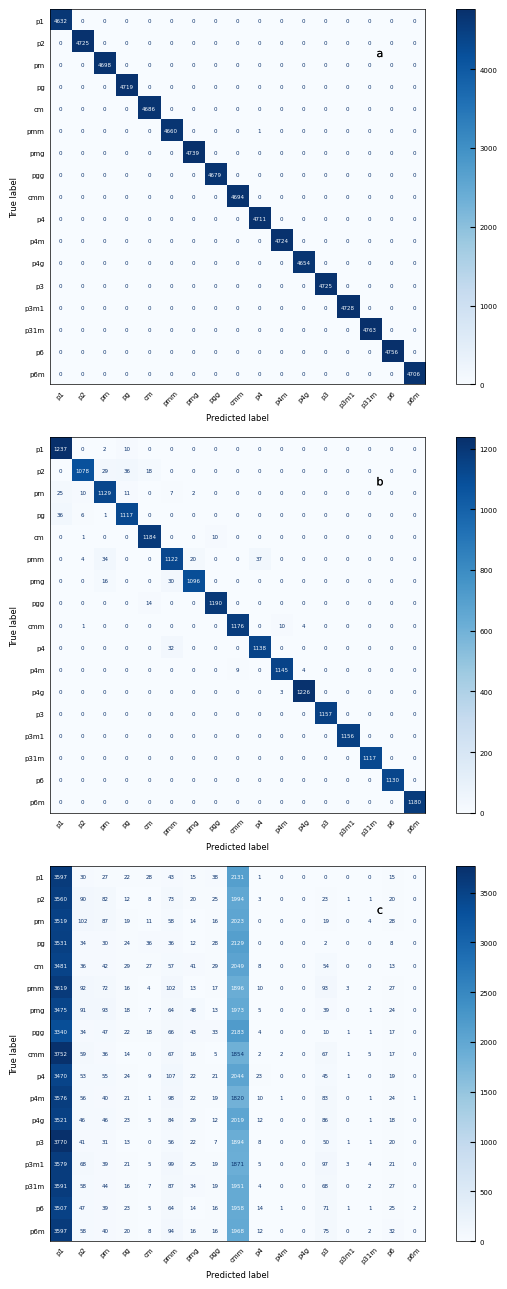

Summary_cm-Train_ImageNet-CrossValidate_Atom


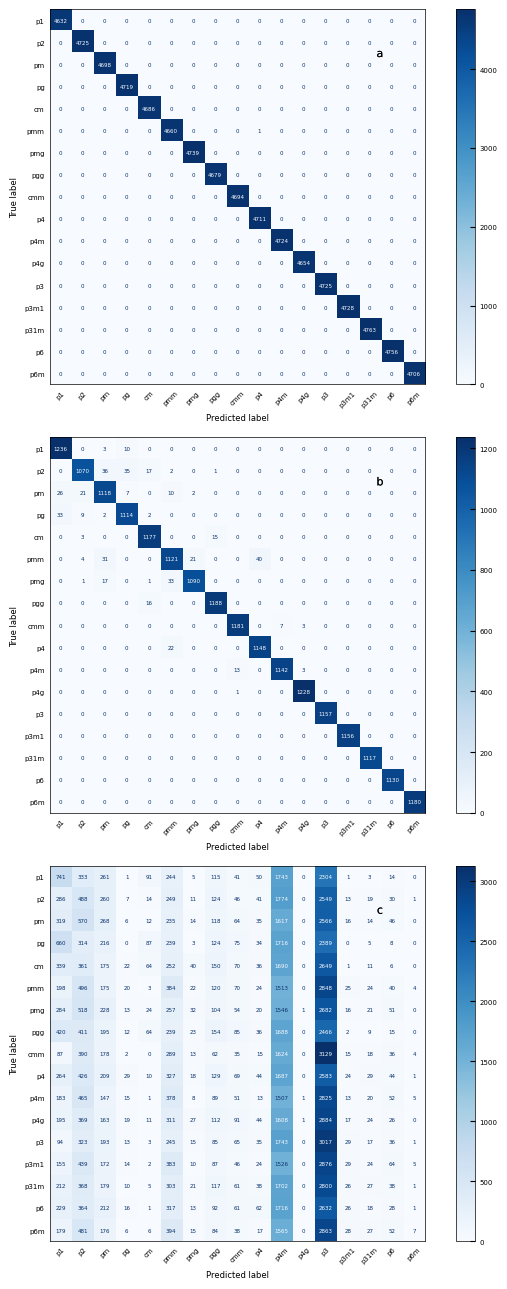

Summary_cm-Train_Noise-CrossValidate_ImageNet


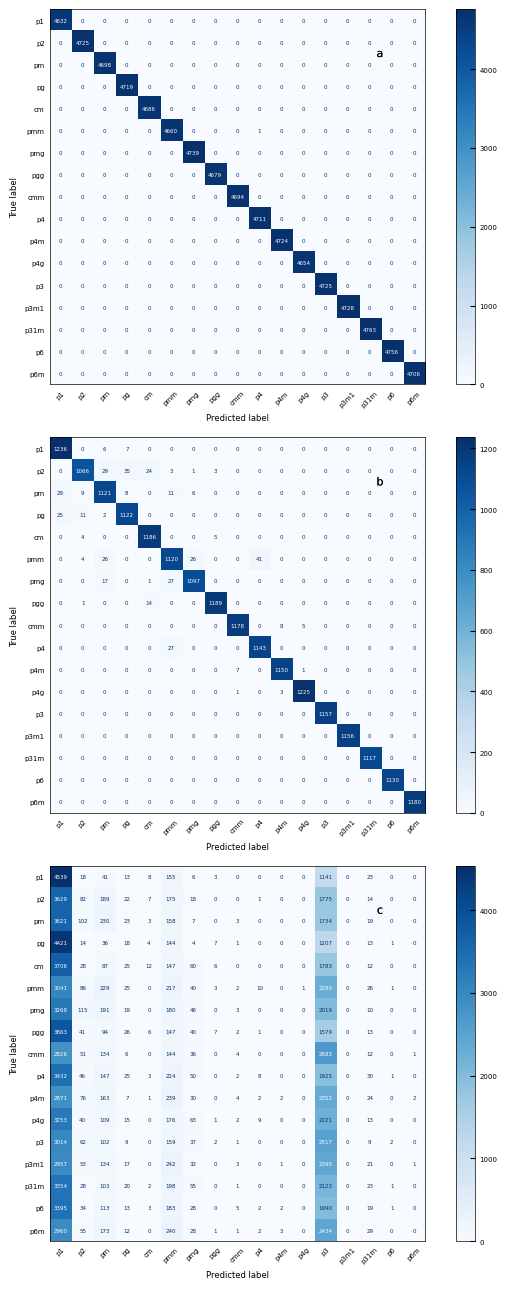

Summary_cm-Train_Atom-CrossValidate_ImageNet


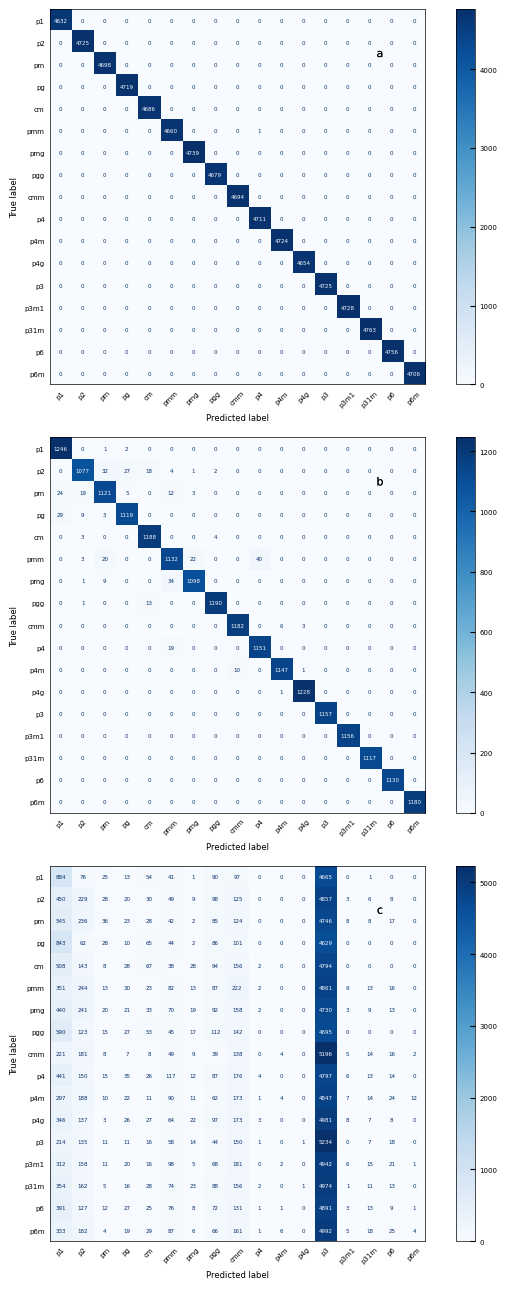

Summary_cm-Train_Noise-CrossValidate_Atom


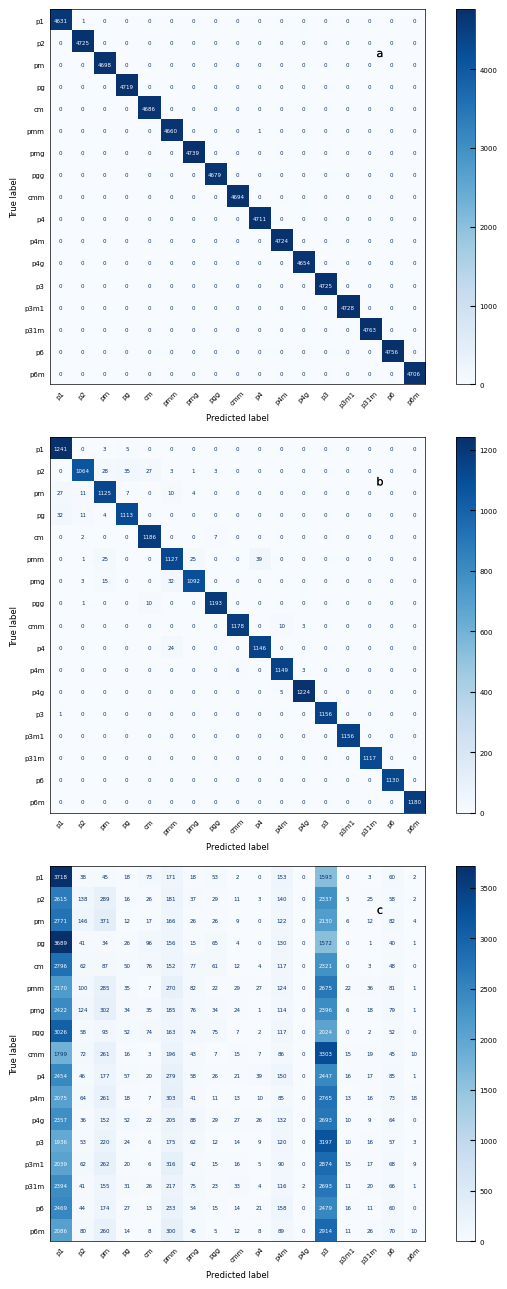

Summary_cm-Train_Atom-CrossValidate_Noise


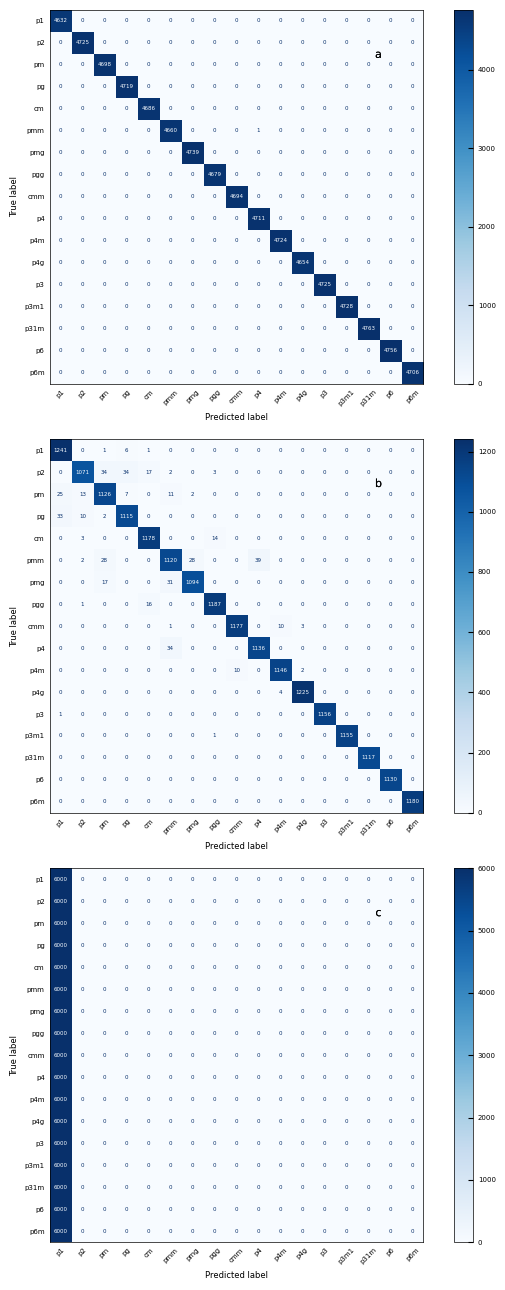

In [73]:
for key, files in grouped_file_paths.items():
    parts = files[0].split('/')[-1].split('-v4')[0]
    NAME = 'Summary_cm-' + key.split('/')[-1]
    print(NAME)
    fig, axes = plt.subplots(3, 1, figsize=(6.5, 13))
    for i, (ax, file) in enumerate(zip(axes, files)):
        cm = np.load(file)
        plot_cm(cm, symmetry_classes, title=None, ax=ax, cm_style='simple', fig_style='printing', fig_index=i, font_size=4)
    plt.tight_layout()
    plt.savefig(f'../../figures/Benchmark/{NAME}.png', bbox_inches='tight')
    plt.savefig(f'../../figures/Benchmark/{NAME}.svg', bbox_inches='tight')
    plt.show()

In [ ]:
parts = sorted_files[0].split('/')[-1].split('-v4')[0]
NAME = 'Summary_cm-' + '-'.join(parts.split('-')[1:])
print(NAME)

fig, axes = plt.subplots(3, 1, figsize=(6.5, 13))
for i, (ax, file) in enumerate(zip(axes, sorted_files)):
    cm = np.load(file)
    plot_cm(cm, symmetry_classes, title=None, ax=ax, cm_style='simple', fig_style='printing', fig_index=i, font_size=4)
plt.tight_layout()
plt.savefig(f'../../figures/Benchmark/{NAME}.png', bbox_inches='tight')
plt.savefig(f'../../figures/Benchmark/{NAME}.svg', bbox_inches='tight')
plt.show()

## Feature_Pyramid

In [ ]:
files = glob.glob('../../saved_results/Benchmark/ResNet50/*')
sorted_files = sorted(files, key=sort_key)
sorted_files

['../../saved_results/Benchmark/ResNet50/05312023-benchmark-resnet50_from_scratch-v4_10m-train_cm.npy',
 '../../saved_results/Benchmark/ResNet50/05312023-benchmark-resnet50_from_scratch-v4_10m-valid_cm.npy',
 '../../saved_results/Benchmark/ResNet50/05312023-benchmark-resnet50_from_scratch-v4_10m-test_cm.npy']

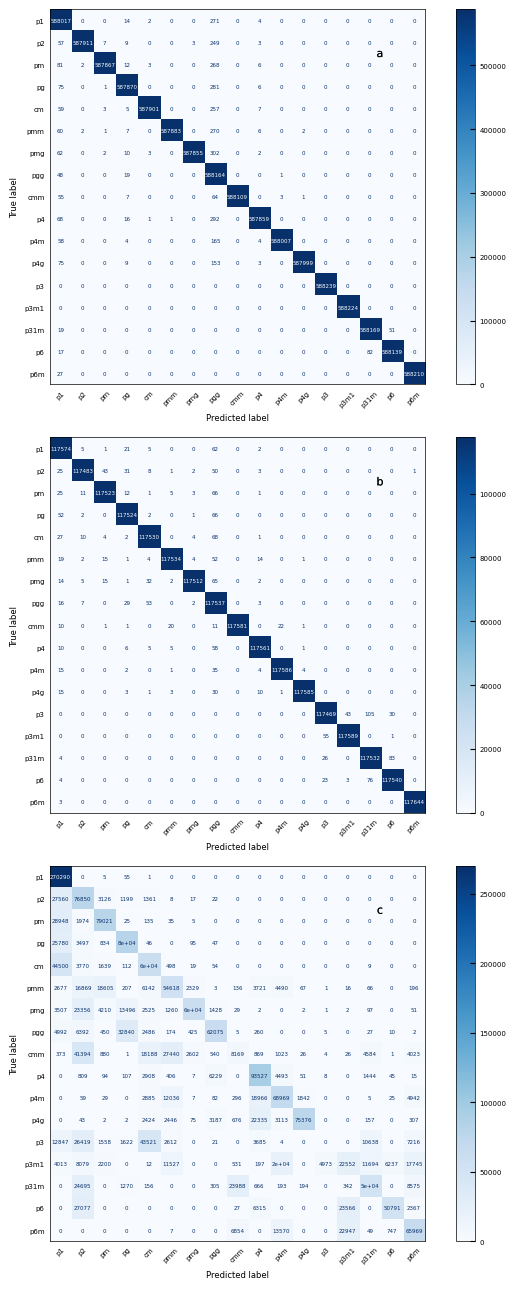

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(6.5, 13))
for i, (ax, file) in enumerate(zip(axes, sorted_files)):
    cm = np.load(file)
    plot_cm(cm, symmetry_classes, title=None, ax=ax, cm_style='simple', fig_style='printing', fig_index=i, font_size=4)
plt.tight_layout()
plt.savefig('test.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
# folders = glob.glob('../../saved_results/Benchmark/*')
# folders.remove('../../saved_results/Benchmark/Cross_Validation-ResNet50')
# files = []
# for folder in folders:
#     files += glob.glob(folder + '/*')
# files.sort()
# files

files = glob.glob('../../saved_results/Benchmark/XCiT/*')
files

['../../saved_results/Benchmark/XCiT/01102024-benchmark-XCiT-v4_10m-test_cm.npy',
 '../../saved_results/Benchmark/XCiT/01102024-benchmark-XCiT-v4_10m-train_cm.npy',
 '../../saved_results/Benchmark/XCiT/01102024-benchmark-XCiT-v4_10m-valid_cm.npy']

In [3]:
order = ['train', 'valid', 'test']

def sort_key(file_path):
    for index, key in enumerate(order):
        if key in file_path:
            return index
    return len(order)

sorted_file_paths = sorted(files, key=sort_key)
sorted_file_paths

['../../saved_results/Benchmark/DenseNet161/01122024-benchmark-DenseNet161-v4_10m-train_cm.npy',
 '../../saved_results/Benchmark/DenseNet161/01122024-benchmark-DenseNet161-v4_10m-valid_cm.npy',
 '../../saved_results/Benchmark/DenseNet161/01122024-benchmark-DenseNet161-v4_10m-test_cm.npy']

In [31]:
file = '../../saved_results/Benchmark/ResNet50/05312023-benchmark-resnet50_from_scratch-v4_10m-train_cm.npy'
parts = file.split('/')[-1].split('-v4')[0]
NAME = '-'.join(parts.split('-')[1:])
NAME

'benchmark-resnet50_from_scratch'

printing set for seaborn


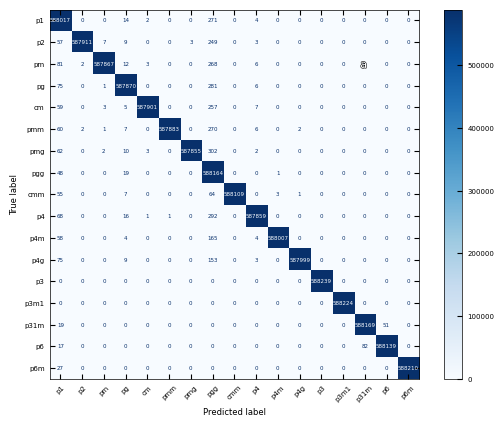

In [16]:
plot_cm(cm, symmetry_classes, title=None, cm_style='simple', fig_style='printing', fig_index=0, font_size=4)
plt.show()

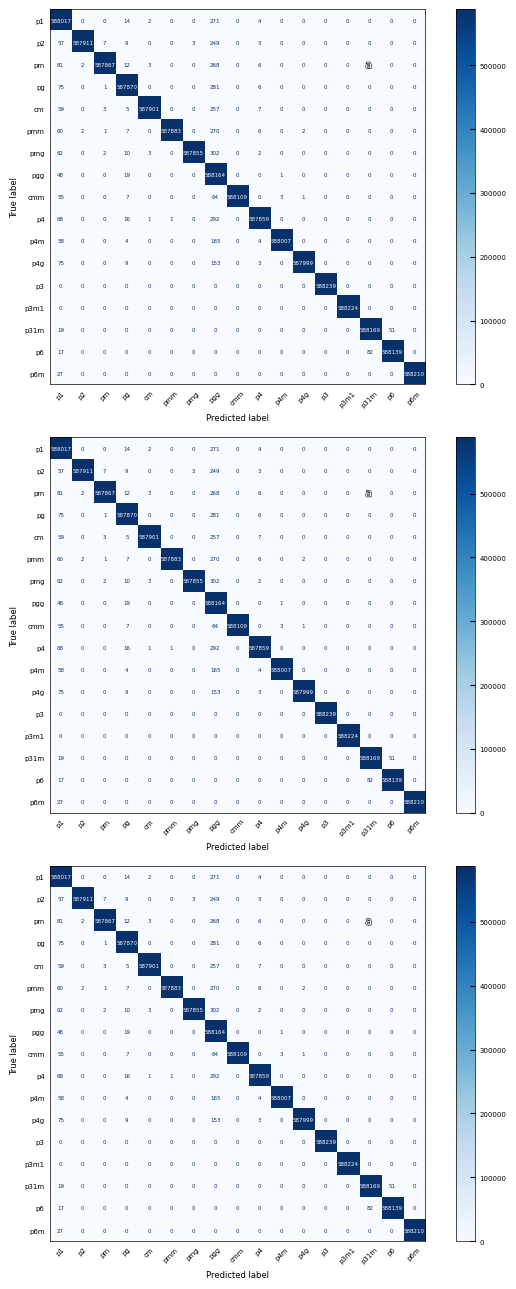

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(6.5, 13))
plot_cm(cm, symmetry_classes, title=None, ax=axes[0], cm_style='simple', fig_style='printing', fig_index=0, font_size=4)
plot_cm(cm, symmetry_classes, title=None, ax=axes[1], cm_style='simple', fig_style='printing', fig_index=0, font_size=4)
plot_cm(cm, symmetry_classes, title=None, ax=axes[2], cm_style='simple', fig_style='printing', fig_index=0, font_size=4)
plt.tight_layout()
plt.savefig('test.png', dpi=300, bbox_inches='tight')
plt.show()
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')